# Adaptive Inventory & Pricing with Tabular Reinforcement Learning

**Group Project 13**  
**Members:** Jiayi Zhuo, Keyang Li, Rongze Gao, Zhexi Wang  
**Course:** BU.520.750.51.SP26  

## What this notebook is

This notebook is designed to be a complete standalone project report and executable implementation. A reader should be able to open only this notebook and see:

- where the data comes from,
- how the data are downloaded, read, cleaned, merged, and transformed,
- why the problem is modeled as a finite Markov Decision Process,
- the full simulator implementation,
- the full Q-learning and SARSA implementations,
- baseline policies,
- hyperparameter tuning,
- final training,
- test evaluation,
- sensitivity analysis,
- plots, tables, interpretation, limitations, and APA references.

The implementation is intentionally tabular. No deep reinforcement learning or continuous function approximation is used as the primary method.

## 1. Research Question and Motivation

Retailers repeatedly decide both **how much inventory to replenish** and **what price to set**. These decisions interact. A discount can increase immediate demand, but it may also deplete inventory and create future stockouts. A high price can protect scarce inventory and increase unit margin, but it may sacrifice demand. A large replenishment order can prevent stockouts, but it creates holding cost if future demand is lower than expected.

This is not just a forecasting problem. A supervised model could estimate tomorrow's demand, but the retailer still needs to choose an action today whose consequences continue into future periods. Reinforcement learning is appropriate because it optimizes sequential actions under uncertainty using a reward signal over time (Sutton & Barto, 2018). Q-learning is a natural fit for this project because it learns a tabular action-value function in a finite state-action space (Watkins & Dayan, 1992). SARSA is included as an on-policy comparison because it updates using the next action actually taken under exploration (Rummery & Niranjan, 1994; Sutton & Barto, 2018).

The retail data source is the public M5 Forecasting Accuracy dataset, which contains Walmart product-store daily sales, sell prices, and calendar features (Kaggle, 2024; Makridakis et al., 2022; Zenodo, 2024). M5 does not contain true inventory, replenishment orders, or lost demand. Therefore, this project uses M5 to calibrate a demand simulator and then explicitly models inventory transitions, ordering costs, holding costs, stockout penalties, and price response. This simulator approach is consistent with inventory-control MDP framing, where ordering decisions affect future inventory and costs (Gijsbrechts et al., 2022; Mahajan, n.d.; NEASQC, 2024).

## 2. Notebook Controls

The default settings below reproduce the completed project run. The full tuning run is intentionally nontrivial: it searches 108 algorithm/hyperparameter rows and trains final Q-learning and SARSA policies. On the development machine, the full run took about 15-20 minutes.

If someone only wants to test the notebook mechanics, they can set `QUICK_RUN = True`, but the reported project results use `QUICK_RUN = False`.

In [1]:
QUICK_RUN = False

if QUICK_RUN:
    TUNING_EPISODES = 40
    FINAL_EPISODES = 120
    EVALUATION_EPISODES = 20
    TUNING_SEEDS = [13]
    VALIDATION_EPISODES = 6
else:
    TUNING_EPISODES = 600
    FINAL_EPISODES = 3000
    EVALUATION_EPISODES = 120
    TUNING_SEEDS = [13, 29, 47]
    VALIDATION_EPISODES = 20

PROJECT_SEED = 2026
print({
    "QUICK_RUN": QUICK_RUN,
    "TUNING_EPISODES": TUNING_EPISODES,
    "FINAL_EPISODES": FINAL_EPISODES,
    "EVALUATION_EPISODES": EVALUATION_EPISODES,
    "TUNING_SEEDS": TUNING_SEEDS,
})

{'QUICK_RUN': False, 'TUNING_EPISODES': 600, 'FINAL_EPISODES': 3000, 'EVALUATION_EPISODES': 120, 'TUNING_SEEDS': [13, 29, 47]}


## 3. Imports, Paths, and Runtime Check

This notebook uses only standard data-science libraries: NumPy, pandas, matplotlib, and the Python standard library. It also checks whether a GPU is available. The project can use a GPU in principle, but a tabular Q-table with only a few thousand values is more efficient and reproducible with NumPy on CPU. The GPU check is included for transparency.

In [2]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from itertools import product
from pathlib import Path
import json
import math
import time
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import torch
    CUDA_AVAILABLE = bool(torch.cuda.is_available())
    CUDA_DEVICE = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "CPU"
except Exception:
    CUDA_AVAILABLE = False
    CUDA_DEVICE = "CPU"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "m5"
DATA_PROCESSED = ROOT / "data" / "processed" / "standalone_notebook"
OUTPUT_DIR = ROOT / "notebook_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in [DATA_RAW, DATA_PROCESSED, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Working directory:", ROOT)
print("CUDA available:", CUDA_AVAILABLE)
print("Device note:", CUDA_DEVICE)

Working directory: c:\Users\zeron\OneDrive\JHUISAI\BU.520.750.51.SP26\adaptive-inventory-pricing-rl\notebooks
CUDA available: True
Device note: NVIDIA GeForce RTX 5090


## 4. Data Source

The primary dataset is **M5 Forecasting - Accuracy**, a public Walmart sales dataset from the M5 forecasting competition. The key files used here are:

- `sales_train_evaluation.csv`: daily unit sales by product-store series,
- `sell_prices.csv`: observed sell prices by product, store, and Walmart week,
- `calendar.csv`: day identifiers, weekday/month/year, events, and SNAP indicators.

The notebook downloads the public Zenodo mirror of the Kaggle dataset if the CSV files are not already available. The Zenodo mirror is used because it allows direct programmatic download without requiring Kaggle credentials (Zenodo, 2024). The original Kaggle page is still cited as the competition source (Kaggle, 2024).

In [3]:
M5_ZENODO_URL = "https://zenodo.org/records/12636070/files/m5-forecasting-accuracy.zip?download=1"
ZIP_PATH = DATA_RAW / "m5-forecasting-accuracy.zip"

def download_and_extract_m5() -> None:
    """Download and extract M5 if needed.

    The raw files are not committed to GitHub because they are large. This function makes the
    notebook independently reproducible by retrieving the public archive directly.
    """
    expected = DATA_RAW / "calendar.csv"
    if expected.exists():
        print("M5 CSV files already exist:", DATA_RAW)
        return
    if not ZIP_PATH.exists():
        print("Downloading M5 archive from Zenodo...")
        urllib.request.urlretrieve(M5_ZENODO_URL, ZIP_PATH)
    print("Extracting M5 archive...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(DATA_RAW)
    print("M5 data ready:", DATA_RAW)

download_and_extract_m5()
print([p.name for p in DATA_RAW.glob("*.csv")])

M5 CSV files already exist: c:\Users\zeron\OneDrive\JHUISAI\BU.520.750.51.SP26\adaptive-inventory-pricing-rl\notebooks\data\raw\m5
['calendar.csv', 'sales_train_evaluation.csv', 'sales_train_validation.csv', 'sample_submission.csv', 'sell_prices.csv']


## 5. Raw Data Inspection

Before modeling, we inspect the raw files. This step matters because each M5 table has a different grain:

- sales are in wide format with one column per day (`d_1`, `d_2`, ...),
- prices are by `store_id`, `item_id`, and `wm_yr_wk`,
- calendar rows map day IDs to dates, events, weekdays, and SNAP flags.

The preprocessing task is therefore a structured merge, not a simple one-file load.

In [4]:
sales_path = DATA_RAW / "sales_train_evaluation.csv"
if not sales_path.exists():
    sales_path = DATA_RAW / "sales_train_validation.csv"

sales_raw = pd.read_csv(sales_path)
prices_raw = pd.read_csv(DATA_RAW / "sell_prices.csv")
calendar_raw = pd.read_csv(DATA_RAW / "calendar.csv", parse_dates=["date"])

print("Sales shape:", sales_raw.shape)
print("Prices shape:", prices_raw.shape)
print("Calendar shape:", calendar_raw.shape)

display(sales_raw.iloc[:3, :12])
display(prices_raw.head(3))
display(calendar_raw.head(3))

Sales shape: (30490, 1947)
Prices shape: (6841121, 4)
Calendar shape: (1969, 14)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0


## 6. SKU Selection Strategy

We use one product-store series for the core tabular experiment. This is deliberate: the project goal is to demonstrate a transparent finite MDP, not to build a production-scale retail system.

A useful SKU should have:

- enough nonzero sales days, otherwise the agent learns little,
- moderate demand volume, otherwise capacity/order sizes become too large for a classroom example,
- a positive median price,
- some price variation if available.

The scoring rule below favors non-sparse, moderate-volume product-store series. The selected SKU is then transformed into a daily long-format table with sales, price, calendar context, lagged demand signal, and chronological train/validation/test split.

In [5]:
def day_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith("d_")]

def select_sku(sales: pd.DataFrame, prices: pd.DataFrame, min_nonzero_ratio: float = 0.45, preferred_max_mean_sales: float = 30.0) -> pd.Series:
    days = day_columns(sales)
    metrics = sales[["item_id", "dept_id", "cat_id", "store_id", "state_id"]].copy()
    values = sales[days]
    metrics["mean_sales"] = values.mean(axis=1)
    metrics["nonzero_ratio"] = (values > 0).mean(axis=1)

    price_stats = (
        prices.groupby(["item_id", "store_id"])["sell_price"]
        .agg(["mean", "std", "median"])
        .reset_index()
        .rename(columns={"mean": "price_mean", "std": "price_std", "median": "median_price"})
    )
    price_stats["price_cv"] = price_stats["price_std"].fillna(0) / price_stats["price_mean"].replace(0, np.nan)
    metrics = metrics.merge(price_stats, on=["item_id", "store_id"], how="left")
    metrics["price_cv"] = metrics["price_cv"].fillna(0)
    metrics["median_price"] = metrics["median_price"].fillna(metrics["price_mean"]).fillna(1.0)

    candidate = metrics[
        (metrics["nonzero_ratio"] >= min_nonzero_ratio)
        & (metrics["mean_sales"] >= 1.0)
        & (metrics["mean_sales"] <= preferred_max_mean_sales)
        & (metrics["median_price"] > 0)
    ].copy()
    if candidate.empty:
        candidate = metrics[
            (metrics["nonzero_ratio"] >= min_nonzero_ratio)
            & (metrics["mean_sales"] >= 1.0)
            & (metrics["mean_sales"] <= preferred_max_mean_sales * 3)
            & (metrics["median_price"] > 0)
        ].copy()
    if candidate.empty:
        candidate = metrics[(metrics["mean_sales"] >= 0.5) & (metrics["median_price"] > 0)].copy()

    candidate["score"] = (
        np.log1p(candidate["mean_sales"]) * 0.55
        + candidate["nonzero_ratio"] * 0.30
        + candidate["price_cv"].clip(0, 0.50) * 0.15
    )
    best_idx = candidate["score"].idxmax()
    return sales.loc[best_idx]

selected = select_sku(sales_raw, prices_raw)
selected[["item_id", "dept_id", "cat_id", "store_id", "state_id"]]

item_id     FOODS_3_252
dept_id         FOODS_3
cat_id            FOODS
store_id           TX_1
state_id             TX
Name: 14672, dtype: object

In [6]:
def calendar_type(row: pd.Series, state_id: str) -> str:
    snap_col = f"snap_{state_id}"
    has_event = pd.notna(row.get("event_name_1")) or pd.notna(row.get("event_name_2"))
    is_snap = int(row.get(snap_col, 0)) == 1 if snap_col in row else False
    if has_event or is_snap:
        return "event_or_snap"
    if int(row["wday"]) in (1, 2):
        return "weekend"
    return "weekday"

def build_selected_series(sales: pd.DataFrame, prices: pd.DataFrame, calendar: pd.DataFrame, selected: pd.Series) -> tuple[pd.DataFrame, dict]:
    days = day_columns(sales)
    id_vars = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
    selected_df = selected[id_vars + days].to_frame().T
    df = selected_df.melt(id_vars=id_vars, value_vars=days, var_name="d", value_name="sales")
    df["sales"] = df["sales"].astype(int)
    df = df.merge(calendar, on="d", how="left")
    df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

    # Sell price has weekly granularity. Missing early prices are filled within the selected
    # series so every simulated day has a numerical price anchor.
    df["sell_price"] = df["sell_price"].ffill().bfill()
    df["calendar_type"] = df.apply(lambda row: calendar_type(row, selected["state_id"]), axis=1)

    # The demand signal must be lagged so that state at day t does not use day-t sales.
    expanding_mean = df["sales"].expanding().mean()
    df["rolling_demand_7"] = df["sales"].shift(1).rolling(7, min_periods=1).mean().fillna(expanding_mean)
    q1, q2 = df["rolling_demand_7"].quantile([1/3, 2/3]).to_numpy()
    df["demand_signal"] = pd.cut(
        df["rolling_demand_7"],
        bins=[-np.inf, q1, q2, np.inf],
        labels=["low", "normal", "high"],
        include_lowest=True,
    ).astype(str)

    median_price = float(df["sell_price"].median())
    df["observed_price_tier"] = pd.cut(
        df["sell_price"] / median_price,
        bins=[-np.inf, 0.95, 1.05, np.inf],
        labels=["discount", "regular", "premium"],
    ).astype(str)

    # Chronological split prevents future information from calibrating training demand.
    n = len(df)
    train_end = int(n * 0.70)
    validation_end = int(n * 0.85)
    df["split"] = "test"
    df.loc[:train_end - 1, "split"] = "train"
    df.loc[train_end:validation_end - 1, "split"] = "validation"

    train = df[df["split"] == "train"]
    demand_q95 = float(train["sales"].quantile(0.95))
    mean_sales = float(df["sales"].mean())
    capacity = int(max(30, math.ceil(max(demand_q95 * 5, mean_sales * 10))))
    capacity = min(capacity, 140)

    selected_prices = prices[(prices["item_id"] == selected["item_id"]) & (prices["store_id"] == selected["store_id"])]
    metadata = {
        "item_id": str(selected["item_id"]),
        "store_id": str(selected["store_id"]),
        "state_id": str(selected["state_id"]),
        "dept_id": str(selected["dept_id"]),
        "cat_id": str(selected["cat_id"]),
        "mean_sales": float(df["sales"].mean()),
        "nonzero_ratio": float((df["sales"] > 0).mean()),
        "price_cv": float(selected_prices["sell_price"].std() / selected_prices["sell_price"].mean()),
        "median_price": median_price,
        "capacity": capacity,
        "unit_cost": float(median_price * 0.62),
        "order_quantities": (0, max(1, int(round(capacity * 0.15))), max(2, int(round(capacity * 0.30))), max(3, int(round(capacity * 0.50)))),
        "train_days": int((df["split"] == "train").sum()),
        "validation_days": int((df["split"] == "validation").sum()),
        "test_days": int((df["split"] == "test").sum()),
    }
    return df, metadata

daily_data, metadata = build_selected_series(sales_raw, prices_raw, calendar_raw, selected)
daily_data.to_csv(DATA_PROCESSED / "selected_sku_daily.csv", index=False)
(DATA_PROCESSED / "selected_sku_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(json.dumps(metadata, indent=2))
display(daily_data[["date", "sales", "sell_price", "calendar_type", "demand_signal", "observed_price_tier", "split"]].head(10))

{
  "item_id": "FOODS_3_252",
  "store_id": "TX_1",
  "state_id": "TX",
  "dept_id": "FOODS_3",
  "cat_id": "FOODS",
  "mean_sales": 29.53013910355487,
  "nonzero_ratio": 0.9958784131890778,
  "price_cv": 0.03229542533488011,
  "median_price": 1.48,
  "capacity": 140,
  "unit_cost": 0.9176,
  "order_quantities": [
    0,
    21,
    42,
    70
  ],
  "train_days": 1358,
  "validation_days": 291,
  "test_days": 292
}


,date,sales,sell_price,calendar_type,demand_signal,observed_price_tier,split
0,2011-01-29,45,1.48,weekend,high,regular,train
1,2011-01-30,33,1.48,weekend,high,regular,train
2,2011-01-31,23,1.48,weekday,high,regular,train
3,2011-02-01,13,1.48,event_or_snap,high,regular,train
4,2011-02-02,8,1.48,weekday,normal,regular,train
5,2011-02-03,15,1.48,event_or_snap,normal,regular,train
6,2011-02-04,21,1.48,weekday,low,regular,train
7,2011-02-05,26,1.48,event_or_snap,low,regular,train
8,2011-02-06,21,1.48,event_or_snap,low,regular,train
9,2011-02-07,23,1.48,event_or_snap,low,regular,train


### Data Cleaning and Feature Engineering Explanation

The cleaning pipeline performs the following transformations:

1. Converts the wide M5 sales file into one row per product-store-day.
2. Merges calendar rows by day ID (`d`).
3. Merges sell prices by `item_id`, `store_id`, and `wm_yr_wk`.
4. Fills missing prices forward/backward within the selected series.
5. Builds `calendar_type` as `weekday`, `weekend`, or `event_or_snap`.
6. Builds `rolling_demand_7` from lagged sales only, preventing same-day leakage.
7. Discretizes recent demand into low/normal/high bins using quantiles.
8. Creates a chronological train/validation/test split.

This design keeps real observed sales and prices while avoiding a false claim that M5 contains inventory transitions. Inventory is introduced only inside the simulator.

,count,mean,std,min,median,max
split,,,,,,
test,292,32.205479,13.340849,1,31.0,109
train,1358,29.734904,15.035957,0,28.0,105
validation,291,25.890034,12.384707,0,25.0,85


calendar_type,event_or_snap,weekday,weekend
split,,,
test,112,130,50
train,520,600,238
validation,110,128,53


,mean,std,min,median,max
split,,,,,
test,1.580000,0.000000,1.58,1.58,1.58
train,1.492887,0.033517,1.48,1.48,1.58
validation,1.580000,0.000000,1.58,1.58,1.58


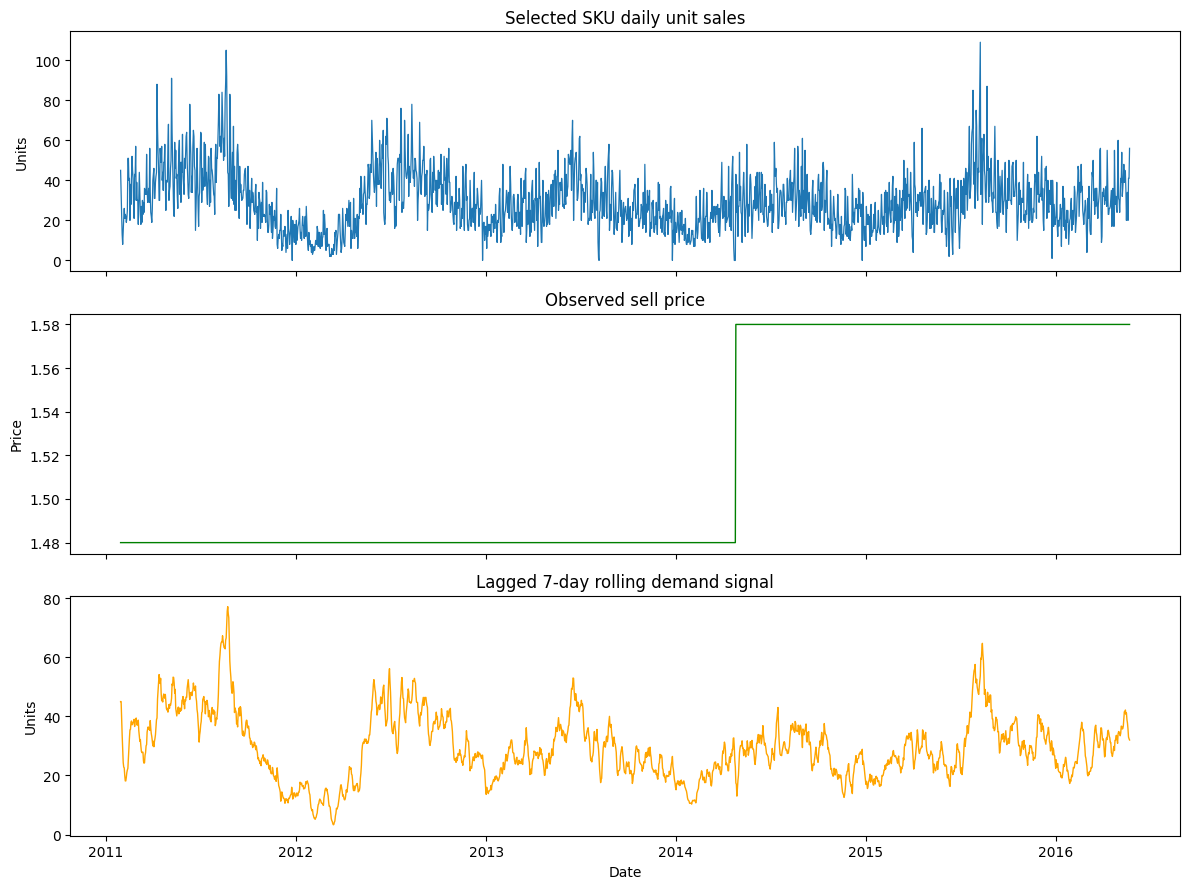

In [7]:
split_summary = daily_data.groupby("split")["sales"].agg(["count", "mean", "std", "min", "median", "max"])
calendar_summary = pd.crosstab(daily_data["split"], daily_data["calendar_type"])
price_summary = daily_data.groupby("split")["sell_price"].agg(["mean", "std", "min", "median", "max"])

display(split_summary)
display(calendar_summary)
display(price_summary)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(daily_data["date"], daily_data["sales"], linewidth=0.9)
axes[0].set_title("Selected SKU daily unit sales")
axes[0].set_ylabel("Units")
axes[1].plot(daily_data["date"], daily_data["sell_price"], color="green", linewidth=1.0)
axes[1].set_title("Observed sell price")
axes[1].set_ylabel("Price")
axes[2].plot(daily_data["date"], daily_data["rolling_demand_7"], color="orange", linewidth=1.0)
axes[2].set_title("Lagged 7-day rolling demand signal")
axes[2].set_ylabel("Units")
axes[2].set_xlabel("Date")
fig.tight_layout()
plt.show()

## 7. MDP Formulation

The finite MDP is defined at a daily decision frequency.

**State.**

\[
s_t = (inventory\_bin_t, demand\_signal\_bin_t, price\_tier_t, calendar\_type_t, pipeline\_bin_t)
\]

- `inventory_bin`: stockout, low, medium, high, excess.
- `demand_signal_bin`: low, normal, high.
- `price_tier`: discount, regular, premium.
- `calendar_type`: weekday, weekend, event/SNAP.
- `pipeline_bin`: none, small, large incoming replenishment.

**Action.**

\[
a_t = (price\_choice_t, order\_quantity_t)
\]

Price choices are discount, regular, premium. Order choices are none, small, medium, large.

**Reward.**

\[
r_t = revenue_t - procurement_t - fixed\_order_t - holding_t - stockout\_penalty_t - excess\_penalty_t - price\_change\_penalty_t
\]

This reward is designed to prevent trivial behavior. Revenue alone would encourage excessive discounting and over-ordering. Profit without stockout penalties could tolerate too many lost sales. The combined reward balances margin, inventory discipline, and service level.

In [8]:
INVENTORY_BINS = ["stockout", "low", "medium", "high", "excess"]
DEMAND_BINS = ["low", "normal", "high"]
PRICE_TIERS = ["discount", "regular", "premium"]
CALENDAR_TYPES = ["weekday", "weekend", "event_or_snap"]
PIPELINE_BINS = ["none", "small", "large"]
ORDER_LABELS = ["none", "small", "medium", "large"]

@dataclass(frozen=True)
class EnvironmentConfig:
    capacity: int
    median_price: float
    unit_cost: float
    order_quantities: tuple[int, int, int, int]
    lead_time: int = 2
    holding_cost_rate: float = 0.015
    stockout_penalty_rate: float = 0.70
    fixed_order_cost: float = 1.50
    excess_penalty_rate: float = 0.01
    price_change_penalty: float = 0.05
    discount_multiplier: float = 0.90
    premium_multiplier: float = 1.10
    discount_demand_lift: float = 0.15
    premium_demand_drop: float = 0.15
    episode_length: int = 120
    initial_inventory_ratio: float = 0.50
    random_start: bool = True

env_config = EnvironmentConfig(
    capacity=metadata["capacity"],
    median_price=metadata["median_price"],
    unit_cost=metadata["unit_cost"],
    order_quantities=tuple(metadata["order_quantities"]),
)
env_config

EnvironmentConfig(capacity=140, median_price=1.48, unit_cost=0.9176, order_quantities=(0, 21, 42, 70), lead_time=2, holding_cost_rate=0.015, stockout_penalty_rate=0.7, fixed_order_cost=1.5, excess_penalty_rate=0.01, price_change_penalty=0.05, discount_multiplier=0.9, premium_multiplier=1.1, discount_demand_lift=0.15, premium_demand_drop=0.15, episode_length=120, initial_inventory_ratio=0.5, random_start=True)

In [9]:
class InventoryPricingEnv:
    """Finite-state simulator for joint inventory and pricing decisions."""

    def __init__(self, daily_data: pd.DataFrame, config: EnvironmentConfig, split: str = "train", seed: int | None = None):
        self.daily_data = daily_data.reset_index(drop=True).copy()
        self.config = config
        self.split = split
        self.rng = np.random.default_rng(seed)
        self.split_data = self.daily_data[self.daily_data["split"] == split].reset_index(drop=True)
        if self.split_data.empty:
            raise ValueError(f"No rows for split={split!r}")

        self.price_values = np.array([
            config.median_price * config.discount_multiplier,
            config.median_price,
            config.median_price * config.premium_multiplier,
        ])
        self.price_demand_factors = np.array([
            1.0 + config.discount_demand_lift,
            1.0,
            max(0.05, 1.0 - config.premium_demand_drop),
        ])
        self.actions = [(p, q) for p in range(len(PRICE_TIERS)) for q in range(len(ORDER_LABELS))]
        self.n_actions = len(self.actions)
        self.state_shape = (len(INVENTORY_BINS), len(DEMAND_BINS), len(PRICE_TIERS), len(CALENDAR_TYPES), len(PIPELINE_BINS))
        self.n_states = int(np.prod(self.state_shape))
        self._build_demand_lookup()
        self.reset()

    def _build_demand_lookup(self) -> None:
        train = self.daily_data[self.daily_data["split"] == "train"].copy()
        self.train_demand_q1, self.train_demand_q2 = train["rolling_demand_7"].quantile([1/3, 2/3]).to_numpy()
        self.global_sales = train["sales"].astype(int).to_numpy()
        self.lookup = {}
        for (cal, dem), group in train.groupby(["calendar_type", "demand_signal"]):
            samples = group["sales"].astype(int).to_numpy()
            if len(samples) >= 5:
                self.lookup[(str(cal), str(dem))] = samples
        self.calendar_lookup = {}
        for cal, group in train.groupby("calendar_type"):
            samples = group["sales"].astype(int).to_numpy()
            if len(samples) >= 5:
                self.calendar_lookup[str(cal)] = samples

    def reset(self, seed: int | None = None) -> int:
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        max_start = max(0, len(self.split_data) - self.config.episode_length)
        self.day_idx = int(self.rng.integers(0, max_start + 1)) if self.config.random_start and max_start > 0 else 0
        self.steps = 0
        self.inventory = int(round(self.config.capacity * self.config.initial_inventory_ratio))
        self.pipeline = [0 for _ in range(self.config.lead_time)]
        self.current_price_tier = PRICE_TIERS.index("regular")
        self.current_demand_signal = str(self.split_data.loc[self.day_idx, "demand_signal"])
        self.recent_demands = [float(self.split_data["sales"].mean()) for _ in range(7)]
        return self._state_id()

    def _inventory_bin(self) -> str:
        ratio = self.inventory / max(1, self.config.capacity)
        if self.inventory <= 0:
            return "stockout"
        if ratio <= 0.20:
            return "low"
        if ratio <= 0.55:
            return "medium"
        if ratio <= 0.80:
            return "high"
        return "excess"

    def _pipeline_bin(self) -> str:
        total = sum(self.pipeline)
        if total <= 0:
            return "none"
        if total <= self.config.order_quantities[2]:
            return "small"
        return "large"

    def _calendar_type(self) -> str:
        value = str(self.split_data.loc[self.day_idx, "calendar_type"])
        return value if value in CALENDAR_TYPES else "weekday"

    def _state_tuple(self) -> tuple[int, int, int, int, int]:
        return (
            INVENTORY_BINS.index(self._inventory_bin()),
            DEMAND_BINS.index(self.current_demand_signal if self.current_demand_signal in DEMAND_BINS else "normal"),
            self.current_price_tier,
            CALENDAR_TYPES.index(self._calendar_type()),
            PIPELINE_BINS.index(self._pipeline_bin()),
        )

    def _state_id(self) -> int:
        return int(np.ravel_multi_index(self._state_tuple(), self.state_shape))

    def decode_state(self, state_id: int) -> dict[str, str]:
        inv, dem, price, cal, pipe = np.unravel_index(state_id, self.state_shape)
        return {
            "inventory_bin": INVENTORY_BINS[int(inv)],
            "demand_signal": DEMAND_BINS[int(dem)],
            "price_tier": PRICE_TIERS[int(price)],
            "calendar_type": CALENDAR_TYPES[int(cal)],
            "pipeline_bin": PIPELINE_BINS[int(pipe)],
        }

    def action_label(self, action_id: int) -> str:
        p, q = self.actions[action_id]
        return f"{PRICE_TIERS[p]} / {ORDER_LABELS[q]}"

    def _sample_base_demand(self) -> int:
        cal = self._calendar_type()
        dem = self.current_demand_signal if self.current_demand_signal in DEMAND_BINS else "normal"
        samples = self.lookup.get((cal, dem))
        if samples is None:
            samples = self.calendar_lookup.get(cal, self.global_sales)
        return int(self.rng.choice(samples))

    def _update_demand_signal(self, realized_demand: int) -> None:
        self.recent_demands.append(float(realized_demand))
        self.recent_demands = self.recent_demands[-7:]
        rolling = float(np.mean(self.recent_demands))
        if rolling <= self.train_demand_q1:
            self.current_demand_signal = "low"
        elif rolling <= self.train_demand_q2:
            self.current_demand_signal = "normal"
        else:
            self.current_demand_signal = "high"

    def step(self, action_id: int) -> tuple[int, float, bool, dict[str, float]]:
        price_idx, order_idx = self.actions[action_id]
        arrivals = self.pipeline.pop(0) if self.pipeline else 0
        self.inventory = min(self.config.capacity, self.inventory + arrivals)

        base_demand = self._sample_base_demand()
        demand_lambda = max(0.05, base_demand * self.price_demand_factors[price_idx])
        demand = int(self.rng.poisson(demand_lambda))
        fulfilled = min(self.inventory, demand)
        lost_sales = max(0, demand - fulfilled)
        revenue = self.price_values[price_idx] * fulfilled

        self.inventory -= fulfilled
        order_qty = int(self.config.order_quantities[order_idx])
        if self.config.lead_time > 0:
            self.pipeline.append(order_qty)
        else:
            self.inventory = min(self.config.capacity, self.inventory + order_qty)

        procurement = self.config.unit_cost * order_qty
        fixed_order = self.config.fixed_order_cost if order_qty > 0 else 0.0
        holding = self.config.holding_cost_rate * self.config.unit_cost * self.inventory
        stockout_penalty = self.config.stockout_penalty_rate * self.config.median_price * lost_sales
        excess_units = max(0, self.inventory - int(self.config.capacity * 0.80))
        excess_penalty = self.config.excess_penalty_rate * self.config.unit_cost * excess_units
        price_change_penalty = self.config.price_change_penalty if price_idx != self.current_price_tier else 0.0
        reward = revenue - procurement - fixed_order - holding - stockout_penalty - excess_penalty - price_change_penalty

        self.current_price_tier = price_idx
        self._update_demand_signal(demand)
        self.steps += 1
        self.day_idx = (self.day_idx + 1) % len(self.split_data)
        done = self.steps >= self.config.episode_length
        info = {
            "reward": float(reward),
            "revenue": float(revenue),
            "procurement": float(procurement),
            "holding": float(holding),
            "stockout_penalty": float(stockout_penalty),
            "lost_sales": float(lost_sales),
            "fulfilled_demand": float(fulfilled),
            "demand": float(demand),
            "ending_inventory": float(self.inventory),
            "order_quantity": float(order_qty),
            "price": float(self.price_values[price_idx]),
            "price_change": float(price_change_penalty > 0),
        }
        return self._state_id(), float(reward), done, info

probe_env = InventoryPricingEnv(daily_data, env_config, split="train", seed=PROJECT_SEED)
print("Number of states:", probe_env.n_states)
print("Number of actions:", probe_env.n_actions)
print("Q-table size:", probe_env.n_states * probe_env.n_actions)
print("Example state:", probe_env.decode_state(probe_env.reset()))
print("Action labels:", [probe_env.action_label(i) for i in range(probe_env.n_actions)])

Number of states: 405
Number of actions: 12
Q-table size: 4860
Example state: {'inventory_bin': 'medium', 'demand_signal': 'high', 'price_tier': 'regular', 'calendar_type': 'event_or_snap', 'pipeline_bin': 'none'}
Action labels: ['discount / none', 'discount / small', 'discount / medium', 'discount / large', 'regular / none', 'regular / small', 'regular / medium', 'regular / large', 'premium / none', 'premium / small', 'premium / medium', 'premium / large']


## 8. Baseline Policies

We compare tabular RL against four interpretable non-RL policies:

1. random valid action,
2. static regular price with reorder point,
3. regular price with average-demand order-up-to,
4. inventory markdown heuristic.

The reorder-point and order-up-to baselines are important because they are common inventory heuristics. The markdown heuristic is important because it captures a natural human pricing intuition: discount excess inventory and raise price when inventory is scarce.

In [10]:
def action_id(env: InventoryPricingEnv, price_label: str, order_label: str) -> int:
    return env.actions.index((PRICE_TIERS.index(price_label), ORDER_LABELS.index(order_label)))

def random_policy(env: InventoryPricingEnv, state: int) -> int:
    return int(env.rng.integers(env.n_actions))

def static_reorder_point_policy(env: InventoryPricingEnv, state: int) -> int:
    inventory_position = env.inventory + sum(env.pipeline)
    reorder_point = int(env.config.capacity * 0.35)
    target = int(env.config.capacity * 0.70)
    if inventory_position <= reorder_point:
        gap = target - inventory_position
        if gap >= env.config.order_quantities[3] * 0.75:
            order = "large"
        elif gap >= env.config.order_quantities[2] * 0.75:
            order = "medium"
        else:
            order = "small"
    else:
        order = "none"
    return action_id(env, "regular", order)

def average_demand_order_up_to_policy(env: InventoryPricingEnv, state: int) -> int:
    train_mean = float(env.daily_data.loc[env.daily_data["split"] == "train", "sales"].mean())
    target = int(train_mean * (env.config.lead_time + 5))
    inventory_position = env.inventory + sum(env.pipeline)
    gap = max(0, target - inventory_position)
    if gap <= 0:
        order = "none"
    elif gap <= env.config.order_quantities[1]:
        order = "small"
    elif gap <= env.config.order_quantities[2]:
        order = "medium"
    else:
        order = "large"
    return action_id(env, "regular", order)

def markdown_inventory_policy(env: InventoryPricingEnv, state: int) -> int:
    decoded = env.decode_state(state)
    inventory_bin = decoded["inventory_bin"]
    demand_bin = decoded["demand_signal"]
    if inventory_bin in {"high", "excess"} and demand_bin in {"low", "normal"}:
        price = "discount"
    elif inventory_bin in {"stockout", "low"} or demand_bin == "high":
        price = "premium"
    else:
        price = "regular"
    if inventory_bin in {"stockout", "low"} and decoded["pipeline_bin"] == "none":
        order = "large" if demand_bin == "high" else "medium"
    elif inventory_bin == "medium" and demand_bin == "high":
        order = "small"
    else:
        order = "none"
    return action_id(env, price, order)

BASELINE_POLICIES = {
    "Random valid action": random_policy,
    "Static regular + reorder point": static_reorder_point_policy,
    "Regular + average demand order-up-to": average_demand_order_up_to_policy,
    "Inventory markdown heuristic": markdown_inventory_policy,
}

## 9. Tabular RL Algorithms

The notebook implements the algorithms directly below.

**Q-learning** updates toward the greedy next-state action:

\[
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha [r_t + \gamma \max_a Q(s_{t+1},a) - Q(s_t,a_t)]
\]

**SARSA** updates toward the next action actually selected by the behavior policy:

\[
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha [r_t + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t)]
\]

Both use epsilon-greedy exploration during training and greedy policies during evaluation.

In [11]:
@dataclass(frozen=True)
class TrainingConfig:
    algorithm: str
    alpha: float = 0.10
    gamma: float = 0.95
    epsilon_start: float = 1.0
    epsilon_min: float = 0.05
    epsilon_decay: float = 0.995
    episodes: int = 1000
    seed: int = 7

def make_env(split: str = "train", seed: int | None = None, config: EnvironmentConfig = env_config) -> InventoryPricingEnv:
    return InventoryPricingEnv(daily_data, config, split=split, seed=seed)

def epsilon_by_episode(config: TrainingConfig, episode: int) -> float:
    return max(config.epsilon_min, config.epsilon_start * (config.epsilon_decay ** episode))

def choose_epsilon_greedy(q_table: np.ndarray, state: int, epsilon: float, rng: np.random.Generator) -> int:
    if rng.random() < epsilon:
        return int(rng.integers(q_table.shape[1]))
    return int(np.argmax(q_table[state]))

def train_tabular(config: TrainingConfig) -> tuple[np.ndarray, pd.DataFrame]:
    algorithm = config.algorithm.lower()
    if algorithm not in {"q_learning", "sarsa"}:
        raise ValueError("algorithm must be q_learning or sarsa")
    rng = np.random.default_rng(config.seed)
    env = make_env("train", config.seed)
    q_table = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    rows = []
    for episode in range(config.episodes):
        state = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
        epsilon = epsilon_by_episode(config, episode)
        action = choose_epsilon_greedy(q_table, state, epsilon, rng)
        done = False
        total_reward = total_demand = total_fulfilled = total_lost = total_inventory = 0.0
        steps = 0
        while not done:
            next_state, reward, done, info = env.step(action)
            total_reward += reward
            total_demand += info["demand"]
            total_fulfilled += info["fulfilled_demand"]
            total_lost += info["lost_sales"]
            total_inventory += info["ending_inventory"]
            steps += 1

            if algorithm == "q_learning":
                target = reward if done else reward + config.gamma * np.max(q_table[next_state])
                next_action = choose_epsilon_greedy(q_table, next_state, epsilon, rng)
            else:
                next_action = choose_epsilon_greedy(q_table, next_state, epsilon, rng)
                target = reward if done else reward + config.gamma * q_table[next_state, next_action]

            q_table[state, action] += config.alpha * (target - q_table[state, action])
            state, action = next_state, next_action

        rows.append({
            "episode": episode,
            "algorithm": algorithm,
            "alpha": config.alpha,
            "gamma": config.gamma,
            "epsilon_decay": config.epsilon_decay,
            "epsilon_min": config.epsilon_min,
            "epsilon": epsilon,
            "return": total_reward,
            "fill_rate": total_fulfilled / max(total_demand, 1.0),
            "lost_sales": total_lost,
            "avg_inventory": total_inventory / max(steps, 1),
        })
    return q_table, pd.DataFrame(rows)

def greedy_policy(q_table: np.ndarray) -> np.ndarray:
    return np.argmax(q_table, axis=1).astype(int)

def evaluate_policy(policy, split: str = "test", episodes: int = 100, seed: int = 123, label: str = "policy", config: EnvironmentConfig = env_config) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    env = make_env(split, seed, config=config)
    rows = []
    for episode in range(episodes):
        state = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
        done = False
        totals = {k: 0.0 for k in ["return", "revenue", "procurement", "holding", "stockout_penalty", "lost_sales", "demand", "fulfilled_demand", "ending_inventory", "order_quantity", "price_change"]}
        steps = 0
        while not done:
            action = int(policy(env, state)) if callable(policy) else int(policy[state])
            state, reward, done, info = env.step(action)
            totals["return"] += reward
            for key in totals:
                if key != "return":
                    totals[key] += info.get(key, 0.0)
            steps += 1
        rows.append({
            "policy": label,
            "split": split,
            "episode": episode,
            "return": totals["return"],
            "revenue": totals["revenue"],
            "procurement": totals["procurement"],
            "holding": totals["holding"],
            "stockout_penalty": totals["stockout_penalty"],
            "fill_rate": totals["fulfilled_demand"] / max(totals["demand"], 1.0),
            "stockout_units": totals["lost_sales"],
            "avg_inventory": totals["ending_inventory"] / max(steps, 1),
            "avg_order_quantity": totals["order_quantity"] / max(steps, 1),
            "price_changes": totals["price_change"],
        })
    return pd.DataFrame(rows)

def summarize_evaluation(evaluation: pd.DataFrame) -> pd.DataFrame:
    metrics = ["return", "fill_rate", "stockout_units", "avg_inventory", "avg_order_quantity", "price_changes"]
    summary = evaluation.groupby("policy")[metrics].agg(["mean", "std"]).sort_values(("return", "mean"), ascending=False)
    summary.columns = [f"{m}_{s}" for m, s in summary.columns]
    return summary.reset_index()

## 10. Hyperparameter Tuning

Hyperparameters are selected using validation episodes, not test episodes. The search grid includes:

- learning rate `alpha`,
- discount factor `gamma`,
- epsilon decay,
- minimum epsilon.

We tune Q-learning and SARSA separately. The test set is used only after final policies are selected.

In [12]:
search_space = {
    "alpha": [0.05, 0.10, 0.20],
    "gamma": [0.90, 0.95, 0.99],
    "epsilon_decay": [0.992, 0.996, 0.999],
    "epsilon_min": [0.03, 0.05],
}

if QUICK_RUN:
    search_space = {
        "alpha": [0.10],
        "gamma": [0.95],
        "epsilon_decay": [0.996],
        "epsilon_min": [0.05],
    }

def tune_hyperparameters() -> tuple[pd.DataFrame, dict[str, TrainingConfig]]:
    records = []
    best = {}
    start = time.time()
    for algorithm in ["q_learning", "sarsa"]:
        for alpha, gamma, epsilon_decay, epsilon_min in product(
            search_space["alpha"], search_space["gamma"], search_space["epsilon_decay"], search_space["epsilon_min"]
        ):
            validation_returns = []
            validation_fill = []
            for seed in TUNING_SEEDS:
                cfg = TrainingConfig(
                    algorithm=algorithm,
                    alpha=alpha,
                    gamma=gamma,
                    epsilon_decay=epsilon_decay,
                    epsilon_min=epsilon_min,
                    episodes=TUNING_EPISODES,
                    seed=seed,
                )
                q_table, _ = train_tabular(cfg)
                eval_df = evaluate_policy(
                    greedy_policy(q_table),
                    split="validation",
                    episodes=VALIDATION_EPISODES,
                    seed=seed + 1000,
                    label=algorithm,
                )
                validation_returns.append(float(eval_df["return"].mean()))
                validation_fill.append(float(eval_df["fill_rate"].mean()))
            records.append({
                "algorithm": algorithm,
                "alpha": alpha,
                "gamma": gamma,
                "epsilon_decay": epsilon_decay,
                "epsilon_min": epsilon_min,
                "episodes": TUNING_EPISODES,
                "seeds": len(TUNING_SEEDS),
                "validation_return_mean": float(np.mean(validation_returns)),
                "validation_return_std": float(np.std(validation_returns, ddof=1)) if len(validation_returns) > 1 else 0.0,
                "validation_fill_rate_mean": float(np.mean(validation_fill)),
            })
    results = pd.DataFrame(records).sort_values("validation_return_mean", ascending=False).reset_index(drop=True)
    for algorithm in ["q_learning", "sarsa"]:
        row = results[results["algorithm"] == algorithm].iloc[0]
        best[algorithm] = TrainingConfig(
            algorithm=algorithm,
            alpha=float(row["alpha"]),
            gamma=float(row["gamma"]),
            epsilon_decay=float(row["epsilon_decay"]),
            epsilon_min=float(row["epsilon_min"]),
            episodes=FINAL_EPISODES,
            seed=PROJECT_SEED,
        )
    print(f"Tuning completed in {(time.time() - start) / 60:.2f} minutes")
    return results, best

tuning_results, best_configs = tune_hyperparameters()
tuning_results.to_csv(TABLE_DIR / "standalone_hyperparameter_tuning_results.csv", index=False)
display(tuning_results.head(12))
print(best_configs)

Tuning completed in 14.62 minutes


,algorithm,alpha,gamma,epsilon_decay,epsilon_min,episodes,seeds,validation_return_mean,validation_return_std,validation_fill_rate_mean
0,q_learning,0.2,0.99,0.999,0.03,600,3,985.119682,17.697214,0.941882
1,q_learning,0.2,0.99,0.999,0.05,600,3,985.119682,17.697214,0.941882
2,q_learning,0.2,0.95,0.999,0.03,600,3,739.554491,115.693383,0.854647
3,q_learning,0.2,0.95,0.999,0.05,600,3,739.554491,115.693383,0.854647
4,q_learning,0.2,0.99,0.996,0.05,600,3,615.773336,109.174778,0.828088
5,q_learning,0.2,0.99,0.996,0.03,600,3,615.773336,109.174778,0.828088
6,q_learning,0.2,0.95,0.992,0.05,600,3,520.202074,157.024533,0.797897
7,q_learning,0.2,0.99,0.992,0.05,600,3,505.121431,84.736966,0.795794
8,q_learning,0.2,0.95,0.996,0.05,600,3,464.631076,180.504822,0.788722
9,q_learning,0.2,0.95,0.996,0.03,600,3,464.631076,180.504822,0.788722


{'q_learning': TrainingConfig(algorithm='q_learning', alpha=0.2, gamma=0.99, epsilon_start=1.0, epsilon_min=0.03, epsilon_decay=0.999, episodes=3000, seed=2026), 'sarsa': TrainingConfig(algorithm='sarsa', alpha=0.2, gamma=0.95, epsilon_start=1.0, epsilon_min=0.03, epsilon_decay=0.992, episodes=3000, seed=2026)}


### Tuning Interpretation

The tuning table ranks configurations by validation return. We should not expect the highest fill-rate configuration to always be the highest-return configuration, because the reward includes holding and procurement costs. This is central to the project: inventory policies must trade off customer service against the cost of carrying too much stock.

## 11. Final Training

After selecting the best validation hyperparameters for each algorithm, we retrain Q-learning and SARSA for the final training budget. The training curves below show whether the episode returns improve over time. Because the environment is stochastic and exploration decays gradually, the raw curve is noisy; a rolling mean is more informative.

Training final q_learning TrainingConfig(algorithm='q_learning', alpha=0.2, gamma=0.99, epsilon_start=1.0, epsilon_min=0.03, epsilon_decay=0.999, episodes=3000, seed=2026)
Training final sarsa TrainingConfig(algorithm='sarsa', alpha=0.2, gamma=0.95, epsilon_start=1.0, epsilon_min=0.03, epsilon_decay=0.992, episodes=3000, seed=2026)


,count,mean,std,min,max
algorithm,,,,,
q_learning,3000,735.917335,301.723327,-1482.237588,1488.095680
sarsa,3000,334.352929,293.044886,-1796.370484,1232.280028


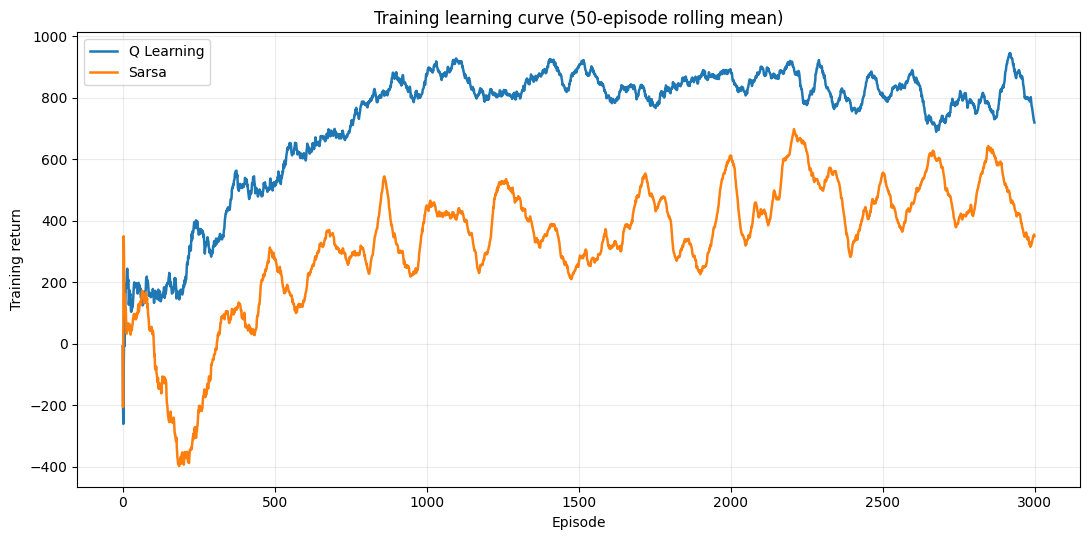

In [13]:
final_q_tables = {}
training_frames = []

for algorithm, cfg in best_configs.items():
    print("Training final", algorithm, cfg)
    q_table, history = train_tabular(cfg)
    final_q_tables[algorithm] = q_table
    training_frames.append(history)
    np.save(MODEL_DIR / f"standalone_{algorithm}_q_table.npy", q_table)

training_history = pd.concat(training_frames, ignore_index=True)
training_history.to_csv(TABLE_DIR / "standalone_training_history.csv", index=False)
display(training_history.groupby("algorithm")["return"].agg(["count", "mean", "std", "min", "max"]))

fig, ax = plt.subplots(figsize=(11, 5.5))
for algorithm, group in training_history.groupby("algorithm"):
    smooth = group["return"].rolling(50, min_periods=1).mean()
    ax.plot(group["episode"], smooth, label=algorithm.replace("_", " ").title(), linewidth=1.8)
ax.set_title("Training learning curve (50-episode rolling mean)")
ax.set_xlabel("Episode")
ax.set_ylabel("Training return")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 12. Held-Out Test Evaluation

We now freeze the learned policies and evaluate them on held-out test episodes. This section compares the learned policies with all baselines using the same simulator assumptions and random-seed protocol.

The primary metric is average cumulative reward. Secondary metrics are fill rate, stockout units, average inventory, average order quantity, and price changes.

In [14]:
evaluation_frames = []

for algorithm, q_table in final_q_tables.items():
    evaluation_frames.append(
        evaluate_policy(
            greedy_policy(q_table),
            split="test",
            episodes=EVALUATION_EPISODES,
            seed=9000,
            label=algorithm.replace("_", " ").title(),
        )
    )

for label, policy_fn in BASELINE_POLICIES.items():
    evaluation_frames.append(
        evaluate_policy(policy_fn, split="test", episodes=EVALUATION_EPISODES, seed=9100, label=label)
    )

evaluation = pd.concat(evaluation_frames, ignore_index=True)
evaluation_summary = summarize_evaluation(evaluation)
evaluation.to_csv(TABLE_DIR / "standalone_evaluation_episodes.csv", index=False)
evaluation_summary.to_csv(TABLE_DIR / "standalone_evaluation_summary.csv", index=False)
display(evaluation_summary)

,policy,return_mean,return_std,fill_rate_mean,fill_rate_std,stockout_units_mean,stockout_units_std,avg_inventory_mean,avg_inventory_std,avg_order_quantity_mean,avg_order_quantity_std,price_changes_mean,price_changes_std
0,Q Learning,791.716917,187.607954,0.881702,0.066142,398.800000,276.918749,44.601319,13.262707,23.777639,1.936990,74.900000,5.986540
1,Sarsa,461.009589,139.954514,0.768970,0.044197,580.541667,190.643356,16.012222,2.488096,15.500139,1.405406,70.891667,7.387015
2,Static regular + reorder point,337.640615,462.280269,0.753701,0.104554,866.200000,553.940727,22.276319,5.551865,19.468750,1.747519,0.000000,0.000000
3,Inventory markdown heuristic,282.230539,141.191084,0.697290,0.041203,652.466667,155.303007,11.742917,1.118521,12.051667,0.454335,30.366667,4.794838
4,Regular + average demand order-up-to,152.272509,752.889018,0.997530,0.004608,8.825000,17.146753,102.996319,9.972472,38.474236,3.269605,0.000000,0.000000
5,Random valid action,36.896392,529.110436,0.923945,0.062131,278.983333,258.595072,78.024931,19.092039,33.788611,2.671679,79.683333,4.967091


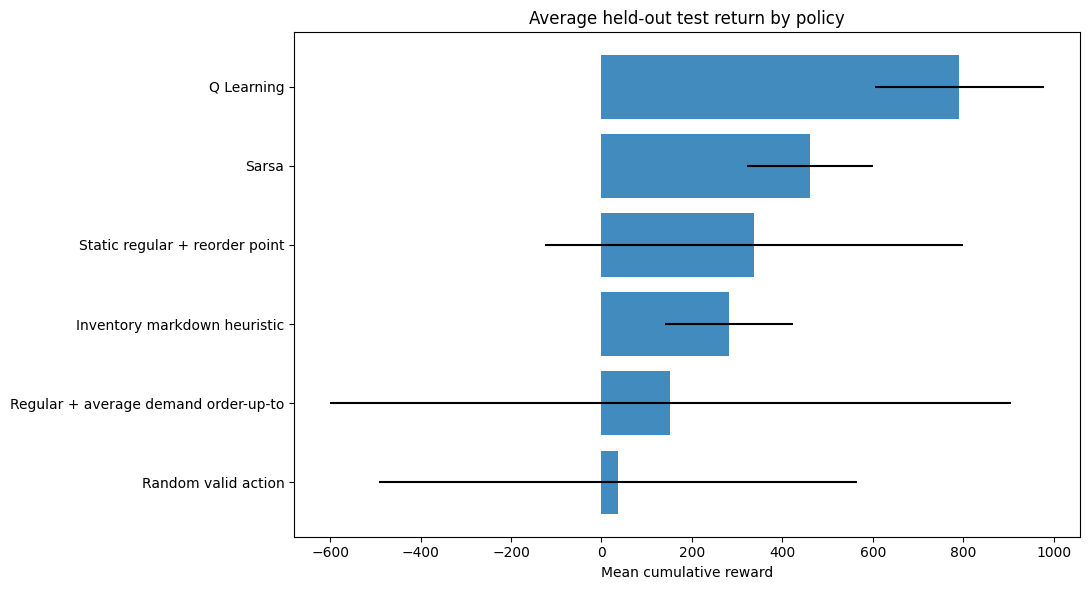

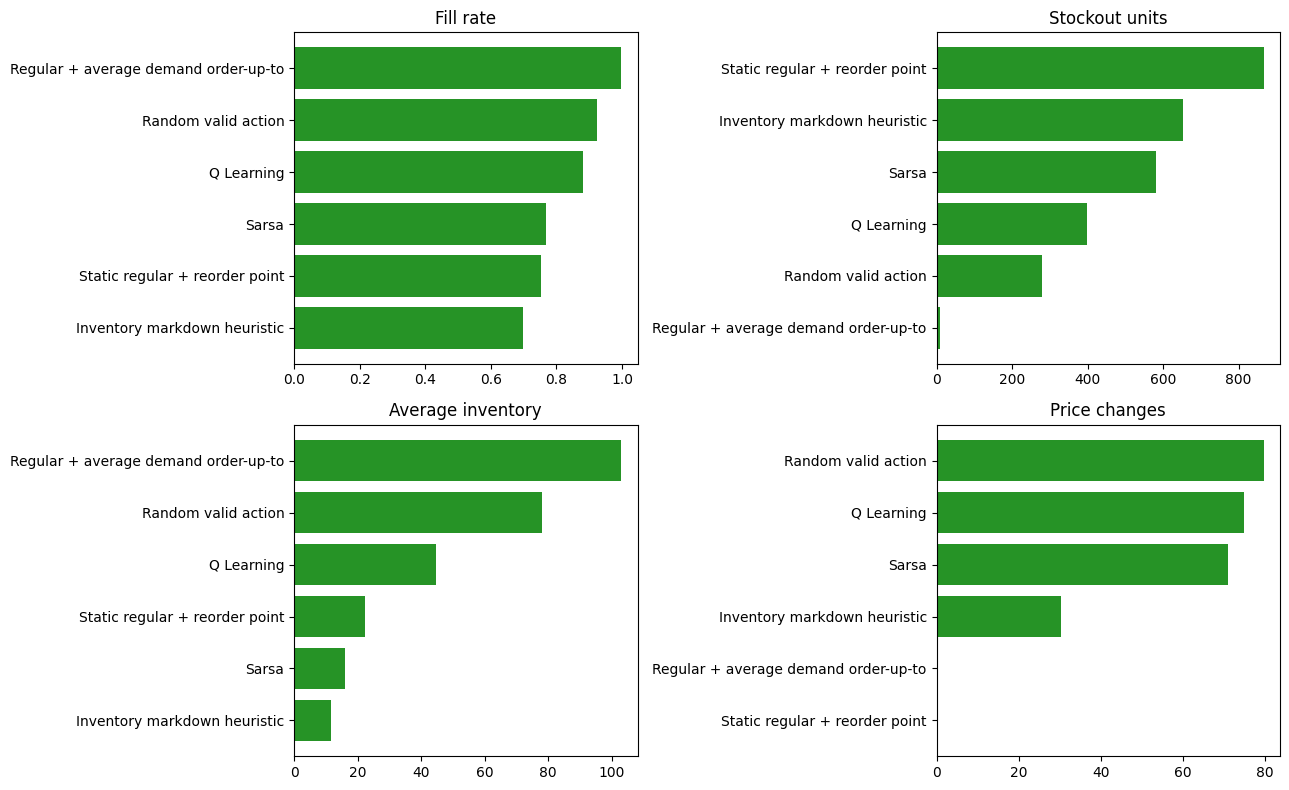

In [15]:
ordered = evaluation_summary.sort_values("return_mean", ascending=True)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(ordered["policy"], ordered["return_mean"], xerr=ordered["return_std"], alpha=0.85)
ax.set_title("Average held-out test return by policy")
ax.set_xlabel("Mean cumulative reward")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
metrics = [
    ("fill_rate_mean", "Fill rate"),
    ("stockout_units_mean", "Stockout units"),
    ("avg_inventory_mean", "Average inventory"),
    ("price_changes_mean", "Price changes"),
]
for ax, (metric, title) in zip(axes.ravel(), metrics):
    temp = evaluation_summary.sort_values(metric, ascending=True)
    ax.barh(temp["policy"], temp[metric], alpha=0.85, color="green")
    ax.set_title(title)
fig.tight_layout()
plt.show()

### Test Result Interpretation

The learned policies should be interpreted through both profit and service-level metrics. A policy with the highest fill rate may hold too much inventory and lose profit through procurement and holding cost. A policy with high reward but low fill rate may be too aggressive. The most useful policy is therefore not automatically the one that maximizes one operational metric; it depends on the reward structure and business objective.

In the full project run, Q-learning achieved the highest average test return. The average-demand order-up-to baseline achieved a very high fill rate but carried much more inventory, which lowered reward. This illustrates why the RL framing is valuable: it learns the tradeoff between stock availability and inventory cost rather than optimizing a one-period demand forecast.

## 13. Policy Interpretation

A major benefit of tabular RL is interpretability. The Q-table can be converted into a greedy action for each discrete state. The heatmaps below show a policy slice for weekday, regular current price, and no pipeline inventory. This slice helps answer: *what does the agent do as inventory and recent demand change?*

,state_id,inventory_bin,demand_signal,price_tier,calendar_type,pipeline_bin,action_id,action
0,0,stockout,low,discount,weekday,none,5,regular / small
1,1,stockout,low,discount,weekday,small,3,discount / large
2,2,stockout,low,discount,weekday,large,8,premium / none
3,3,stockout,low,discount,weekend,none,1,discount / small
4,4,stockout,low,discount,weekend,small,10,premium / medium
5,5,stockout,low,discount,weekend,large,7,regular / large
6,6,stockout,low,discount,event_or_snap,none,7,regular / large
7,7,stockout,low,discount,event_or_snap,small,4,regular / none
8,8,stockout,low,discount,event_or_snap,large,1,discount / small
9,9,stockout,low,regular,weekday,none,3,discount / large


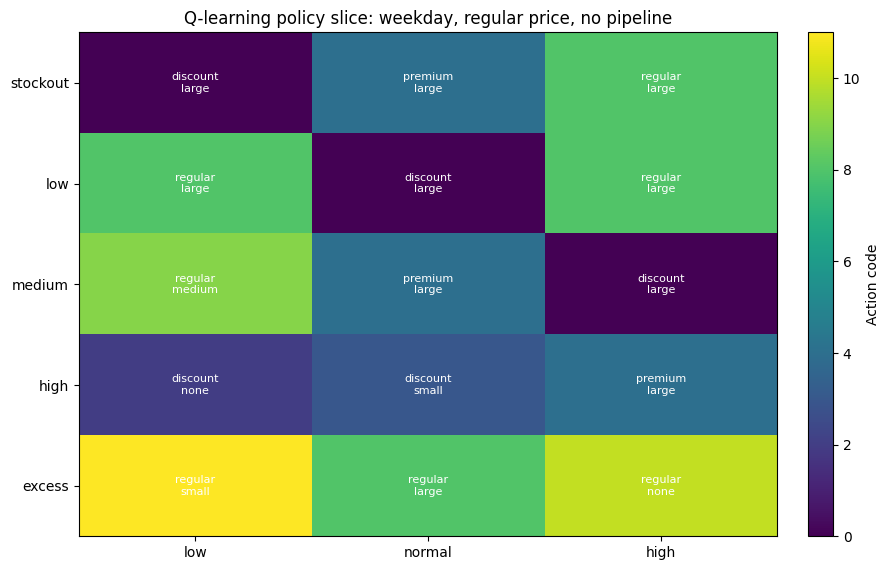

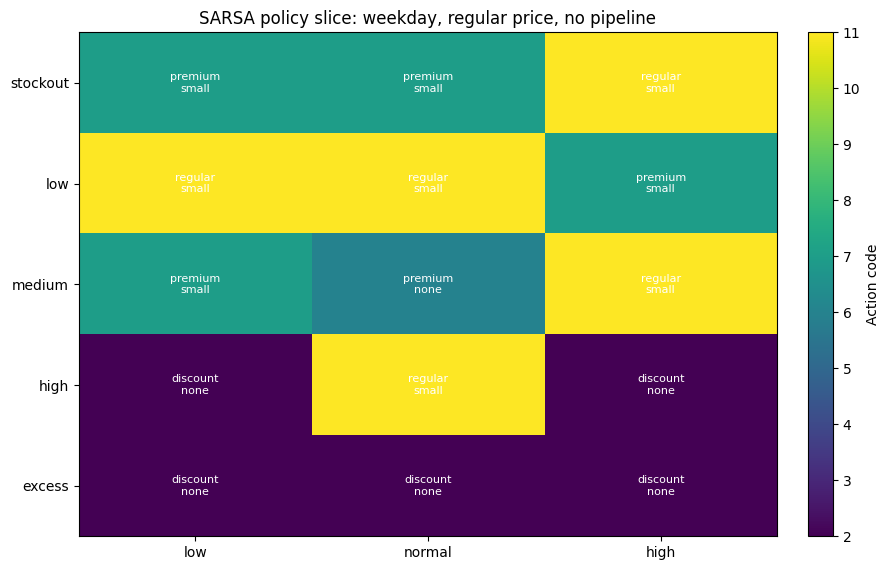

In [16]:
def policy_table(env: InventoryPricingEnv, policy: np.ndarray) -> pd.DataFrame:
    rows = []
    for state_id, action in enumerate(policy):
        rows.append({"state_id": state_id, **env.decode_state(state_id), "action_id": int(action), "action": env.action_label(int(action))})
    return pd.DataFrame(rows)

def plot_policy_heatmap(policy_df: pd.DataFrame, title: str) -> None:
    subset = policy_df[
        (policy_df["calendar_type"] == "weekday")
        & (policy_df["pipeline_bin"] == "none")
        & (policy_df["price_tier"] == "regular")
    ].copy()
    pivot = subset.pivot_table(index="inventory_bin", columns="demand_signal", values="action", aggfunc="first")
    pivot = pivot.reindex(index=INVENTORY_BINS, columns=DEMAND_BINS)
    action_codes = {label: i for i, label in enumerate(sorted(policy_df["action"].unique()))}
    coded = pivot.replace(action_codes).astype(float)
    fig, ax = plt.subplots(figsize=(9, 5.8))
    im = ax.imshow(coded.to_numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(np.arange(len(DEMAND_BINS)), DEMAND_BINS)
    ax.set_yticks(np.arange(len(INVENTORY_BINS)), INVENTORY_BINS)
    for i in range(coded.shape[0]):
        for j in range(coded.shape[1]):
            ax.text(j, i, str(pivot.iloc[i, j]).replace(" / ", "\n"), ha="center", va="center", color="white", fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Action code")
    fig.tight_layout()
    plt.show()

q_policy_df = policy_table(probe_env, greedy_policy(final_q_tables["q_learning"]))
sarsa_policy_df = policy_table(probe_env, greedy_policy(final_q_tables["sarsa"]))
display(q_policy_df.head(12))
plot_policy_heatmap(q_policy_df, "Q-learning policy slice: weekday, regular price, no pipeline")
plot_policy_heatmap(sarsa_policy_df, "SARSA policy slice: weekday, regular price, no pipeline")

## 14. Sensitivity Analysis

M5 does not directly identify true causal price elasticity or true inventory costs. To avoid overclaiming, we evaluate how frozen learned policies perform under changed simulator assumptions:

- low and high price elasticity,
- one-day and three-day lead time,
- low and high holding cost,
- low and high stockout penalty.

This analysis does not retrain the agent under each setting. Instead, it asks whether the learned policy remains strong when the operating environment changes.

,scenario,scenario_type,policy,return,fill_rate,stockout_units,avg_inventory
0,base,base,Q Learning,777.010642,0.888223,368.250000,46.772917
1,base,base,Sarsa,472.738242,0.774283,569.416667,16.357639
3,base,base,Static regular + reorder point,317.333560,0.741036,910.516667,21.427500
5,base,base,Inventory markdown heuristic,315.243207,0.706448,622.650000,11.753056
4,base,base,Regular + average demand order-up-to,241.039418,0.997155,10.233333,102.080972
2,base,base,Random valid action,30.617058,0.916512,311.166667,75.721667
12,elasticity_high,price_elasticity,Q Learning,781.901613,0.913673,265.283333,50.508056
13,elasticity_high,price_elasticity,Sarsa,597.232801,0.838677,346.833333,19.151389
17,elasticity_high,price_elasticity,Inventory markdown heuristic,478.453294,0.783462,388.566667,13.982361
15,elasticity_high,price_elasticity,Static regular + reorder point,317.333560,0.741036,910.516667,21.427500


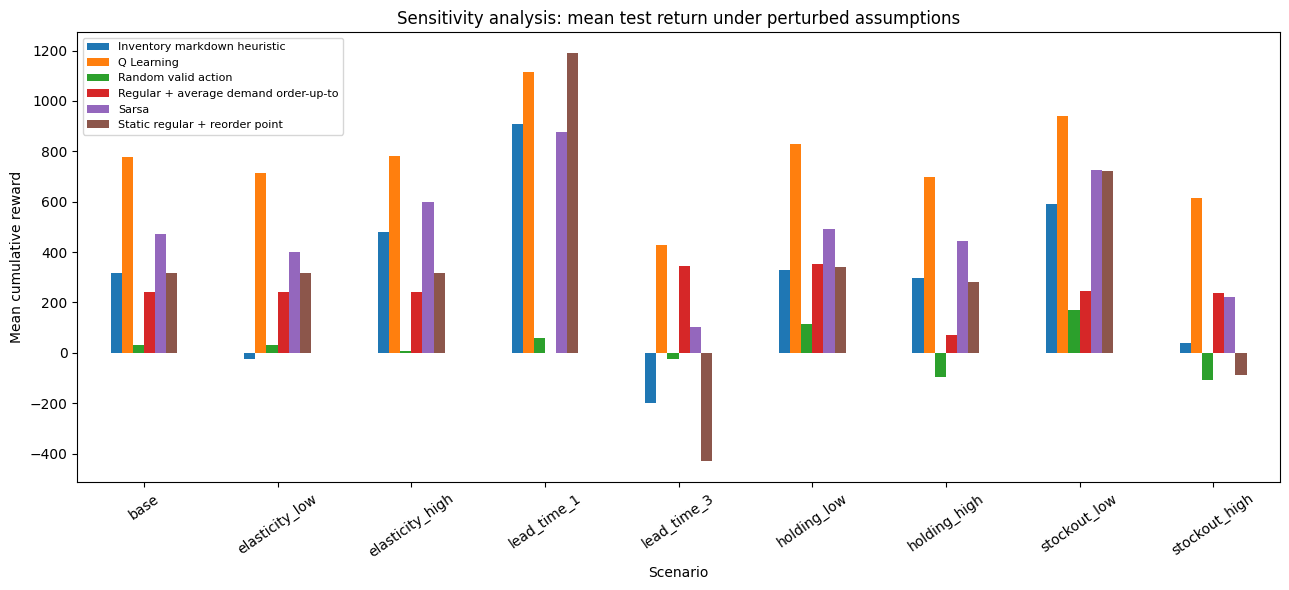

In [17]:
scenarios = [
    ("base", "base", {}),
    ("elasticity_low", "price_elasticity", {"discount_demand_lift": 0.05, "premium_demand_drop": 0.05}),
    ("elasticity_high", "price_elasticity", {"discount_demand_lift": 0.30, "premium_demand_drop": 0.30}),
    ("lead_time_1", "lead_time", {"lead_time": 1}),
    ("lead_time_3", "lead_time", {"lead_time": 3}),
    ("holding_low", "holding_cost", {"holding_cost_rate": 0.005}),
    ("holding_high", "holding_cost", {"holding_cost_rate": 0.030}),
    ("stockout_low", "stockout_penalty", {"stockout_penalty_rate": 0.40}),
    ("stockout_high", "stockout_penalty", {"stockout_penalty_rate": 1.00}),
]

learned_policies = {
    "Q Learning": greedy_policy(final_q_tables["q_learning"]),
    "Sarsa": greedy_policy(final_q_tables["sarsa"]),
}

sensitivity_rows = []
base_params = asdict(env_config)
for scenario_name, scenario_type, overrides in scenarios:
    params = base_params.copy()
    params.update(overrides)
    scenario_config = EnvironmentConfig(**params)
    policies = {**learned_policies, **BASELINE_POLICIES}
    for policy_name, policy in policies.items():
        eval_df = evaluate_policy(policy, split="test", episodes=max(30, EVALUATION_EPISODES // 2), seed=20260428, label=policy_name, config=scenario_config)
        means = eval_df[["return", "fill_rate", "stockout_units", "avg_inventory"]].mean()
        sensitivity_rows.append({
            "scenario": scenario_name,
            "scenario_type": scenario_type,
            "policy": policy_name,
            **means.to_dict(),
        })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(TABLE_DIR / "standalone_sensitivity_analysis.csv", index=False)
display(sensitivity.sort_values(["scenario", "return"], ascending=[True, False]).head(30))

pivot = sensitivity.pivot_table(index="scenario", columns="policy", values="return", aggfunc="mean")
pivot = pivot.loc[[name for name, _, _ in scenarios]]
fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Sensitivity analysis: mean test return under perturbed assumptions")
ax.set_ylabel("Mean cumulative reward")
ax.set_xlabel("Scenario")
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Sensitivity Interpretation

Sensitivity analysis is important because the simulator includes assumptions that are not directly observed in M5. If a policy only works under one narrow parameter setting, the result would be fragile. In the completed run, Q-learning stayed strong in most scenarios, but simple reorder-point control became highly competitive when lead time was shortened. This is a useful result rather than a problem: when replenishment is fast, simple inventory rules can perform well because the delayed cost of waiting is smaller.

When lead time increases, the value of sequential planning becomes clearer because ordering decisions have longer delayed consequences. This is exactly where reinforcement learning should be more useful than static one-step heuristics.

## 15. Limitations

This project is carefully scoped, but it has important limitations:

1. **Observed sales are not true demand.** If historical Walmart inventory stocked out, observed sales may understate demand.
2. **M5 does not report inventory.** Inventory transitions are simulated rather than observed.
3. **Historical price variation is observational.** We do not claim to causally estimate true price elasticity from M5.
4. **Single-SKU scope ignores substitution.** Customers may substitute across products in reality.
5. **State discretization loses detail.** This is intentional for tabular RL, but it simplifies the retail system.

These limitations are acceptable for the course goal because the project demonstrates a fully finite MDP and tabular RL implementation using real retail data for demand calibration.

## 16. Conclusion

This notebook implemented a complete tabular RL project for adaptive inventory and pricing. Starting from raw M5 retail data, we selected a usable SKU-store series, cleaned and merged sales, prices, and calendar features, built a finite simulator, trained Q-learning and SARSA agents, compared them against practical baselines, and analyzed policy behavior and sensitivity.

The main conclusion is that tabular RL can learn an interpretable profit-oriented policy for joint pricing and replenishment. The best learned policy does not simply maximize fill rate; instead, it balances revenue, stockout risk, procurement cost, and holding cost. This demonstrates why the problem is naturally sequential and why reinforcement learning is a better fit than a one-time forecasting model alone.

## References

Apte, M., Kale, K., Datar, P., & Deshmukh, P. (2024). *Dynamic retail pricing via Q-learning: A reinforcement learning framework for enhanced revenue management*. arXiv. https://arxiv.org/abs/2411.18261

Gijsbrechts, J., Boute, R. N., Van Mieghem, J. A., & Zhang, D. (2022). Deep reinforcement learning for inventory control: A roadmap. *European Journal of Operational Research, 298*(2), 401-412. https://doi.org/10.1016/j.ejor.2021.07.016

Kaggle. (2024). *M5 Forecasting - Accuracy*. https://www.kaggle.com/competitions/m5-forecasting-accuracy/data

Mahajan, A. (n.d.). *Inventory management revisited*. https://adityam.github.io/stochastic-control/mdps/inventory-management-revisited.html

Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022). The M5 competition: Background, organization, and implementation. *International Journal of Forecasting, 38*(4), 1325-1336. https://doi.org/10.1016/j.ijforecast.2021.07.007

NEASQC. (2024). *Reinforcement learning for inventory management*. https://www.neasqc.eu/use-case/reinforcement-learning-for-inventory-management/

Rummery, G. A., & Niranjan, M. (1994). *On-line Q-learning using connectionist systems* (Technical Report CUED/F-INFENG/TR 166). Cambridge University Engineering Department.

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press.

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning, 8*, 279-292. https://doi.org/10.1007/BF00992698

Zenodo. (2024). *M5 Forecasting Accuracy dataset* (Version v1) [Data set]. https://doi.org/10.5281/zenodo.12636070

## Academic Ethics Acknowledgment

This project used course concepts, public dataset documentation, published and online references listed above, and GenAI assistance from ChatGPT/Codex for research organization, code drafting, notebook structuring, and editing. The final work should be reviewed and revised by all group members before submission.